![BSC AI Factory — Federated Learning — Module 5](assets/headers/federated-learning.jpg)

# 04. Federated learning

**Topic: Module 5 · Walkthrough: Module 8, slide 6**

Train a shared model across four hospitals, compare it with pooled and separate models, then change aggregation and introduce one corrupted update.

**Code co-created by:** Ülkü Tuncer Küçüktaş, Simge Danışoğlu, Tolga Turan, Gizem Acer.


## Setup

Use a fresh **Python 3.11** environment. Run the setup cell first to install any missing or
mismatched packages. If it installs packages, restart the kernel once, then choose **Run All**.
Rerunning the notebook overwrites its generated files.


In [1]:
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        "This pinned course pack requires Python 3.11. "
        "Select a Python 3.11 kernel before installing packages."
    )

REQUIRED = {
    "numpy": "1.26.4",
    "pandas": "2.2.3",
    "scipy": "1.13.1",
    "scikit-learn": "1.5.0",
    "matplotlib": "3.9.4",
    "flwr": "1.15.2",
}


def installed_version(package):
    try:
        return version(package)
    except PackageNotFoundError:
        return None


packages_to_install = [
    f"{package}=={required_version}"
    for package, required_version in REQUIRED.items()
    if installed_version(package) != required_version
]
if packages_to_install:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *packages_to_install]
    )
    raise RuntimeError("Setup finished. Restart the kernel/runtime, then Run All.")

print("Dependencies ready:", {package: version(package) for package in REQUIRED})


Dependencies ready: {'numpy': '1.26.4', 'pandas': '2.2.3', 'scipy': '1.13.1', 'scikit-learn': '1.5.0', 'matplotlib': '3.9.4', 'flwr': '1.15.2'}


In [2]:
import hashlib
import json
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split

from scipy.special import expit
from flwr.client import NumPyClient
from flwr.server.strategy.aggregate import aggregate, aggregate_median

NAVY, BLUE, TEAL, GOLD, RED = "#1C3076", "#3457A6", "#168A88", "#C58A00", "#B53B4A"
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
    }
)

ARTIFACT_DIR = Path("generated/04_federated_learning")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

HEART_HASHES = {
    "processed.cleveland.data": "a74b7efa387bc9d108d7d0115d831fe9b414b29ae7124f331b622b4efa0427c8",
    "processed.hungarian.data": "d1ad108f785768cd3d7e82dc522e6f5a61eea93cccfb3a46ee8076f73fc3d796",
    "processed.switzerland.data": "834a405ccf5b66ab4056bb77794adc8df0b7125186454c0a1d002d33c6c3b314",
    "processed.va.data": "e7c93d8d0d2acdadfa4c5e8de768e2191e7f618b952e29623f1f0d5949ff6b8f",
}
HEART_COLUMNS = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num",
]


def read_hospital(filename):
    """Read the checked course copy, downloading it only when it is missing."""
    data_path = DATA_DIR / filename
    expected_hash = HEART_HASHES[filename]
    if not data_path.exists():
        base_url = (
            "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/"
        )
        downloaded_data = urllib.request.urlopen(base_url + filename, timeout=60).read()
        if hashlib.sha256(downloaded_data).hexdigest() != expected_hash:
            raise ValueError("Downloaded data differs from the checked course copy.")
        data_path.write_bytes(downloaded_data)

    assert hashlib.sha256(data_path.read_bytes()).hexdigest() == expected_hash
    return pd.read_csv(data_path, names=HEART_COLUMNS, na_values="?")


## 1. Prepare each hospital locally

The four files are the UCI Heart Disease data from Cleveland, Hungary, Switzerland and Long Beach.
The target is `num > 0`. We split each site's records before fitting its imputation values.
Missing values, including zero cholesterol or resting blood pressure, are imputed from that site's
training rows only. Fixed shared scaling constants put all clients in the same parameter coordinates;
they are declared below rather than estimated from pooled records.

The ten-feature linear model is deliberately simple; the coded categorical variables are treated as
numeric features, as in the source exercise. It is an educational comparison, not a clinical model.


In [3]:
HOSPITALS = {
    "Cleveland": "processed.cleveland.data",
    "Hungary": "processed.hungarian.data",
    "Switzerland": "processed.switzerland.data",
    "Long Beach": "processed.va.data",
}
FEATURES = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
]
CENTER = np.array([50, 0.5, 2.5, 130, 240, 0.5, 1, 140, 0.5, 1.0])
SCALE = np.array([15, 0.5, 1.5, 30, 100, 0.5, 1, 40, 0.5, 2.0])


def prepare_features(feature_rows, imputation_values):
    """Impute, apply the shared scale, and append the intercept's constant 1."""
    imputed_features = feature_rows.fillna(imputation_values).to_numpy()
    scaled_features = (imputed_features - CENTER) / SCALE
    return np.column_stack([scaled_features, np.ones(len(scaled_features))])


hospital_splits = {}
hospital_summaries = []
for hospital_name, filename in HOSPITALS.items():
    hospital_data = read_hospital(filename)
    raw_features = hospital_data[FEATURES].astype(float).copy()
    raw_features.loc[raw_features.chol == 0, "chol"] = np.nan
    raw_features.loc[raw_features.trestbps == 0, "trestbps"] = np.nan
    labels = (hospital_data.num > 0).astype(int).to_numpy()

    train_indices, test_indices = train_test_split(
        np.arange(len(hospital_data)),
        test_size=0.25,
        random_state=0,
        stratify=labels,
    )
    assert not set(train_indices) & set(test_indices)

    # Fit imputation only on training rows. Use CENTER if a whole column is missing.
    imputation_values = (
        raw_features.iloc[train_indices]
        .median()
        .fillna(pd.Series(CENTER, index=FEATURES))
    )
    train_features = prepare_features(
        raw_features.iloc[train_indices], imputation_values
    )
    test_features = prepare_features(raw_features.iloc[test_indices], imputation_values)
    train_labels = labels[train_indices]
    test_labels = labels[test_indices]
    assert np.isfinite(train_features).all() and np.isfinite(test_features).all()

    hospital_splits[hospital_name] = (
        train_features,
        test_features,
        train_labels,
        test_labels,
    )
    hospital_summaries.append(
        {
            "hospital": hospital_name,
            "train": len(train_indices),
            "test": len(test_indices),
            "train_disease_rate": train_labels.mean(),
            "test_disease_rate": test_labels.mean(),
        }
    )

display(pd.DataFrame(hospital_summaries).round(3))


,hospital,train,test,train_disease_rate,test_disease_rate
0,Cleveland,227,76,0.458,0.461
1,Hungary,220,74,0.359,0.365
2,Switzerland,92,31,0.935,0.935
3,Long Beach,150,50,0.747,0.740


## 2. Define the model and client messages

Each client receives the current weights, takes a few gradient steps on its own records, and
returns updated weights and a patient count. Flower supplies the client interface and
aggregation functions. The clients run sequentially in this notebook, without Ray or background
services. They simulate separate hospitals; they do not run on separate machines.

All models use the same logistic-loss update, initialization and fixed hyperparameters.
Each hospital evaluates the model locally and returns its loss, test-set size and number of
correct predictions.


In [4]:
ROUNDS, LOCAL_STEPS, LEARNING_RATE, L2 = 80, 5, 0.1, 0.01
NUM_PARAMETERS = len(FEATURES) + 1


def logistic_gradient(features, labels, weights):
    """Gradient of mean logistic loss plus L2, excluding the intercept from L2."""
    probabilities = expit(features @ weights)
    prediction_errors = probabilities - labels
    penalty_gradient = L2 * weights.copy()
    penalty_gradient[-1] = 0
    return features.T @ prediction_errors / len(labels) + penalty_gradient


def train_steps(features, labels, initial_weights, steps):
    weights = initial_weights.copy()
    for _ in range(steps):
        gradient = logistic_gradient(features, labels, weights)
        weights -= LEARNING_RATE * gradient
    return weights


def check_parameters(parameters):
    """Each client sends one finite weight vector in the shared coordinates."""
    assert len(parameters) == 1
    assert parameters[0].shape == (NUM_PARAMETERS,)
    assert np.isfinite(parameters[0]).all()


class HospitalClient(NumPyClient):
    def __init__(self, hospital_name):
        self.name = hospital_name
        (
            self.train_features,
            self.test_features,
            self.train_labels,
            self.test_labels,
        ) = hospital_splits[hospital_name]

    def fit(self, parameters, config):
        updated_weights = train_steps(
            self.train_features, self.train_labels, parameters[0], LOCAL_STEPS
        )
        return [updated_weights], len(self.train_labels), {}

    def evaluate(self, parameters, config):
        logits = self.test_features @ parameters[0]
        loss = float(np.mean(np.logaddexp(0, logits) - self.test_labels * logits))
        predictions = (logits >= 0).astype(int)
        correct_count = int((predictions == self.test_labels).sum())
        return loss, len(self.test_labels), {"correct": correct_count}


clients = [HospitalClient(hospital_name) for hospital_name in HOSPITALS]


def evaluate_all(weights):
    """Combine local correct counts without moving patients to the server."""
    evaluations = [client.evaluate([weights], {}) for client in clients]
    total_correct = sum(metrics["correct"] for _, _, metrics in evaluations)
    total_patients = sum(patient_count for _, patient_count, _ in evaluations)
    return total_correct / total_patients


def federate(method="weighted_mean", corrupt_client=None, corrupt_round=5, factor=-20):
    if method not in {"weighted_mean", "median"}:
        raise ValueError(method)

    global_weights = np.zeros(NUM_PARAMETERS)
    round_history = []
    message_sizes = []
    for round_number in range(1, ROUNDS + 1):
        client_messages = []
        for client in clients:
            parameters, patient_count, _ = client.fit([global_weights.copy()], {})
            if client.name == corrupt_client and round_number == corrupt_round:
                # Sign-flip and amplify one update; leave the local dataset unchanged.
                local_update = parameters[0] - global_weights
                parameters = [global_weights + factor * local_update]

            check_parameters(parameters)
            client_messages.append((parameters, patient_count))
            message_sizes.append(int(parameters[0].nbytes))

        if method == "weighted_mean":
            aggregated_parameters = aggregate(client_messages)
        else:
            aggregated_parameters = aggregate_median(client_messages)
        global_weights = aggregated_parameters[0]
        round_history.append(
            {
                "round": round_number,
                "accuracy": evaluate_all(global_weights),
            }
        )

    return global_weights, pd.DataFrame(round_history), message_sizes


federated_weights, federated_history, message_sizes = federate()
assert set(message_sizes) == {NUM_PARAMETERS * 8}
print(
    f"Each client sends {NUM_PARAMETERS} float64 model parameters "
    f"({NUM_PARAMETERS * 8} bytes), plus count/metadata."
)


Each client sends 11 float64 model parameters (88 bytes), plus count/metadata.


## 3. Compare against pooling and training alone

The pooled baseline combines training records for comparison. Federated training does not use
that pooled array. Every model is evaluated on the same held-out patients through local
evaluation. Combining the correct counts gives the accuracy on the full test population.
Per-hospital scores show where an overall score can hide poor performance at one site.


,model,accuracy
0,Pooled,0.814
1,Federated,0.810
2,Cleveland,0.810
3,Hungary,0.745
4,Switzerland,0.580
5,Long Beach,0.753


,Pooled,Federated,Cleveland,Hungary,Switzerland,Long Beach
Cleveland,0.868,0.855,0.868,0.803,0.553,0.711
Hungary,0.797,0.797,0.784,0.770,0.351,0.730
Switzerland,0.839,0.839,0.839,0.613,0.935,0.871
Long Beach,0.740,0.740,0.740,0.700,0.740,0.780


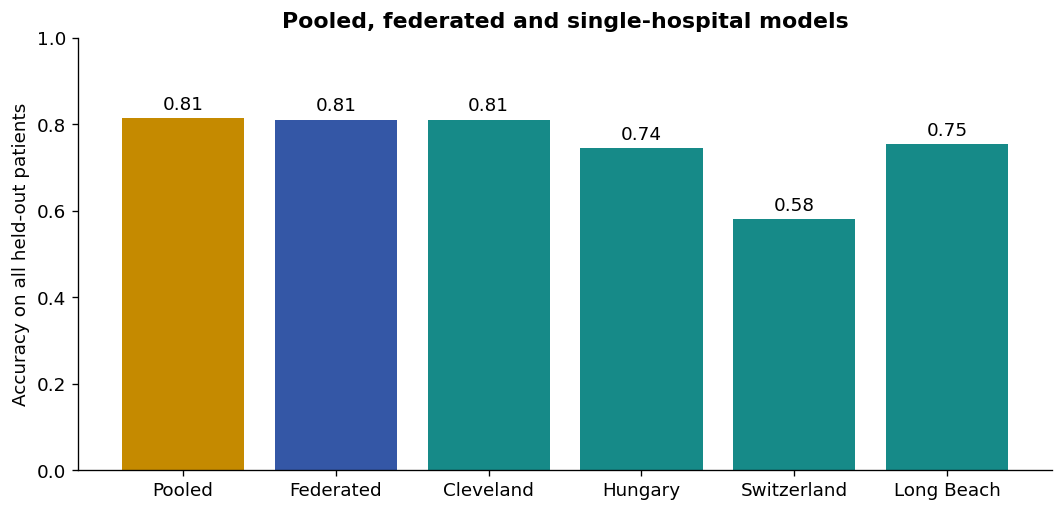

In [5]:
pooled_features = np.vstack([split[0] for split in hospital_splits.values()])
pooled_labels = np.concatenate([split[2] for split in hospital_splits.values()])
pooled_weights = train_steps(
    pooled_features, pooled_labels, np.zeros(NUM_PARAMETERS), ROUNDS * LOCAL_STEPS
)

models = {"Pooled": pooled_weights, "Federated": federated_weights}
for hospital_name, (train_features, _, train_labels, _) in hospital_splits.items():
    models[hospital_name] = train_steps(
        train_features, train_labels, np.zeros(NUM_PARAMETERS), ROUNDS * LOCAL_STEPS
    )

comparison = pd.DataFrame(
    {
        "model": list(models),
        "accuracy": [evaluate_all(weights) for weights in models.values()],
    }
)
display(comparison.round(3))

# Show local scores as well as the combined test-set score.
site_scores_by_model = {}
for model_name, weights in models.items():
    site_scores_by_model[model_name] = {}
    for client in clients:
        _, patient_count, metrics = client.evaluate([weights], {})
        site_scores_by_model[model_name][client.name] = (
            metrics["correct"] / patient_count
        )
site_scores = pd.DataFrame(site_scores_by_model)
display(site_scores.round(3))

figure, axis = plt.subplots(figsize=(9, 4.4))
bars = axis.bar(
    comparison.model, comparison.accuracy, color=[GOLD, BLUE, TEAL, TEAL, TEAL, TEAL]
)
axis.bar_label(bars, fmt="%.2f", padding=3)
axis.set(
    ylim=(0, 1),
    ylabel="Accuracy on all held-out patients",
    title="Pooled, federated and single-hospital models",
)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()
comparison.to_csv(ARTIFACT_DIR / "model_comparison.csv", index=False)
site_scores.to_csv(ARTIFACT_DIR / "per_hospital_accuracy.csv")


## 4. Change aggregation and corrupt one update

Coordinate-wise median ignores sample-size weights and combines each parameter separately. It may
resist an extreme update in this exercise, but four clients and heterogeneous populations do not
establish a general robustness guarantee. Compare both clean and corrupted runs for each method.
Hyperparameters and the corrupted round are fixed before examining test results.


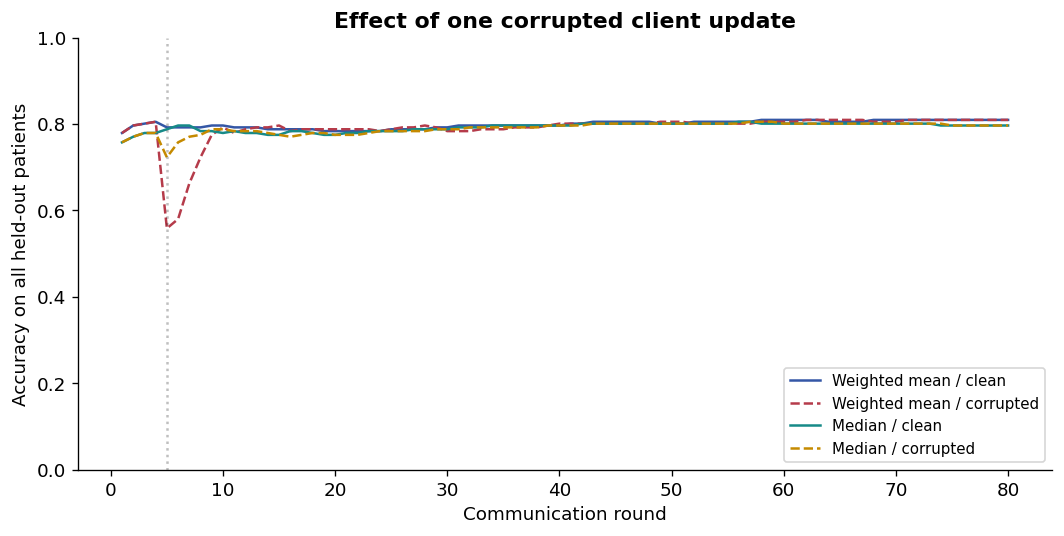

,run,at_corruption,final_accuracy
0,Weighted mean / clean,0.792,0.810
1,Weighted mean / corrupted,0.558,0.810
2,Median / clean,0.788,0.797
3,Median / corrupted,0.723,0.797


Checks passed: disjoint splits, finite inputs/updates, identical test population and one corrupted message.


In [6]:
CORRUPT_CLIENT, CORRUPT_ROUND, CORRUPT_FACTOR = "Cleveland", 5, -20
histories = {"Weighted mean / clean": federated_history}
for method, method_label in [("weighted_mean", "Weighted mean"), ("median", "Median")]:
    if method == "median":
        _, clean_history, _ = federate(method)
        histories[method_label + " / clean"] = clean_history

    _, corrupted_history, _ = federate(
        method,
        corrupt_client=CORRUPT_CLIENT,
        corrupt_round=CORRUPT_ROUND,
        factor=CORRUPT_FACTOR,
    )
    histories[method_label + " / corrupted"] = corrupted_history

figure, axis = plt.subplots(figsize=(9, 4.6))
for (run_name, history), color in zip(histories.items(), [BLUE, RED, TEAL, GOLD]):
    axis.plot(
        history["round"],
        history.accuracy,
        label=run_name,
        color=color,
        ls="--" if "corrupted" in run_name else "-",
    )
axis.axvline(CORRUPT_ROUND, color="black", alpha=0.25, ls=":")
axis.set(
    xlabel="Communication round",
    ylabel="Accuracy on all held-out patients",
    ylim=(0, 1),
    title="Effect of one corrupted client update",
)
axis.legend(fontsize=9, loc="lower right")
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "corrupted_update.png", bbox_inches="tight")
plt.show()

attack_rows = []
for run_name, history in histories.items():
    corruption_accuracy = history.loc[
        history["round"] == CORRUPT_ROUND, "accuracy"
    ].iloc[0]
    attack_rows.append(
        {
            "run": run_name,
            "at_corruption": corruption_accuracy,
            "final_accuracy": history.accuracy.iloc[-1],
        }
    )
attack_summary = pd.DataFrame(attack_rows)
display(attack_summary.round(3))
attack_summary.to_csv(ARTIFACT_DIR / "aggregation_comparison.csv", index=False)
pd.concat(
    [history.assign(run=run_name) for run_name, history in histories.items()]
).to_csv(ARTIFACT_DIR / "round_history.csv", index=False)

assert all(
    history.accuracy.between(0, 1).all() and len(history) == ROUNDS
    for history in histories.values()
)
checks = {
    "hospitals": 4,
    "train_test_disjoint": True,
    "imputation": "local training rows only",
    "shared_scaling": "fixed constants",
    "corrupted_messages_per_attack_run": 1,
    "parameter_bytes_per_client_round": NUM_PARAMETERS * 8,
}
(ARTIFACT_DIR / "checks.json").write_text(json.dumps(checks, indent=2))
print(
    "Checks passed: disjoint splits, finite inputs/updates, "
    "identical test population and one corrupted message."
)


## Experiments

1. Change `LOCAL_STEPS` and rerun the training cells to see the effect of more local work.
2. Change `CORRUPT_FACTOR` or the hospital sending the corrupted update.
3. Compare overall accuracy with each site's accuracy before drawing a conclusion.

Model updates and sample counts can themselves leak information. This notebook does not add secure
aggregation, differential privacy or a protected network transport.

References: [Flower](https://flower.ai/docs/framework/),
[FedAvg paper](https://arxiv.org/abs/1602.05629),
[UCI Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease).


## Optional extension: FedProx and FedAdam

Adapted from `Federated_Learning (1).ipynb`, zero-based cell indices 10, 13, 17, 18, 24 and 25.

FedProx penalizes movement away from the round's starting global weights during local training.
FedAdam changes the server update using first and second moments. Neither method is an attack
defense by itself. This comparison uses clean updates and the same base local loss,
initialization, train/test split, local steps and number of communication rounds for all three
methods. The hyperparameters below are fixed in advance, not selected using test-set results.

Set `RUN_OPTIMIZER_EXTENSION = False` to skip this comparison. Results go into a separate
folder, and checks confirm that the main model's predictions have not changed.


In [7]:
RUN_OPTIMIZER_EXTENSION = True
EXT_PROX_MU = 0.5
EXT_ADAM_ETA, EXT_ADAM_BETA1, EXT_ADAM_BETA2, EXT_ADAM_TAU = 0.1, 0.9, 0.99, 1e-3

from flwr.server.strategy import FedAvg, FedProx, FedAdam
from flwr.common import FitRes, Status, Code
from flwr.common import ndarrays_to_parameters, parameters_to_ndarrays


def train_proximal_steps(features, labels, initial_weights, mu):
    """Add a penalty for moving away from this round's starting global weights."""
    if not np.isfinite(mu) or mu < 0:
        raise ValueError("mu must be finite and nonnegative")

    weights = initial_weights.copy()
    for _ in range(LOCAL_STEPS):
        ordinary_gradient = logistic_gradient(features, labels, weights)
        proximal_gradient = mu * (weights - initial_weights)
        weights -= LEARNING_RATE * (ordinary_gradient + proximal_gradient)
    return weights


class ProximalHospitalClient(HospitalClient):
    def fit(self, parameters, config):
        weights = train_proximal_steps(
            self.train_features,
            self.train_labels,
            parameters[0],
            config["proximal_mu"],
        )
        return [weights], len(self.train_labels), {}


def run_optimizer(method):
    if method not in {"FedAvg", "FedProx", "FedAdam"}:
        raise ValueError(method)

    initial_weights = np.zeros(NUM_PARAMETERS)
    strategy_options = {
        "initial_parameters": ndarrays_to_parameters([initial_weights.copy()]),
        "fit_metrics_aggregation_fn": lambda metrics: {},
    }
    if method == "FedProx":
        strategy = FedProx(proximal_mu=EXT_PROX_MU, **strategy_options)
        local_clients = [ProximalHospitalClient(name) for name in HOSPITALS]
        client_config = {"proximal_mu": strategy.proximal_mu}
    else:
        if method == "FedAvg":
            strategy = FedAvg(**strategy_options)
        else:
            strategy = FedAdam(
                eta=EXT_ADAM_ETA,
                beta_1=EXT_ADAM_BETA1,
                beta_2=EXT_ADAM_BETA2,
                tau=EXT_ADAM_TAU,
                **strategy_options,
            )
        local_clients = [HospitalClient(name) for name in HOSPITALS]
        client_config = {}

    global_weights = initial_weights.copy()
    round_history = []
    for round_number in range(1, ROUNDS + 1):
        replies = []
        for client in local_clients:
            parameters, patient_count, metrics = client.fit(
                [global_weights.copy()], client_config
            )
            check_parameters(parameters)
            fit_result = FitRes(
                status=Status(code=Code.OK, message=""),
                parameters=ndarrays_to_parameters(parameters),
                num_examples=patient_count,
                metrics=metrics,
            )
            # Only FitRes is needed by aggregation; this simulation has no client proxy.
            replies.append((None, fit_result))

        combined_parameters, _ = strategy.aggregate_fit(
            server_round=round_number, results=replies, failures=[]
        )
        if combined_parameters is None:
            raise RuntimeError("No aggregated parameters returned")
        global_weights = parameters_to_ndarrays(combined_parameters)[0]
        assert np.isfinite(global_weights).all()
        round_history.append(
            {
                "round": round_number,
                "accuracy": evaluate_all(global_weights),
            }
        )

    return global_weights, pd.DataFrame(round_history)


,method,rounds,local_steps,final_accuracy
0,FedAvg,80,5,0.8095
1,FedProx,80,5,0.8095
2,FedAdam,80,5,0.8268


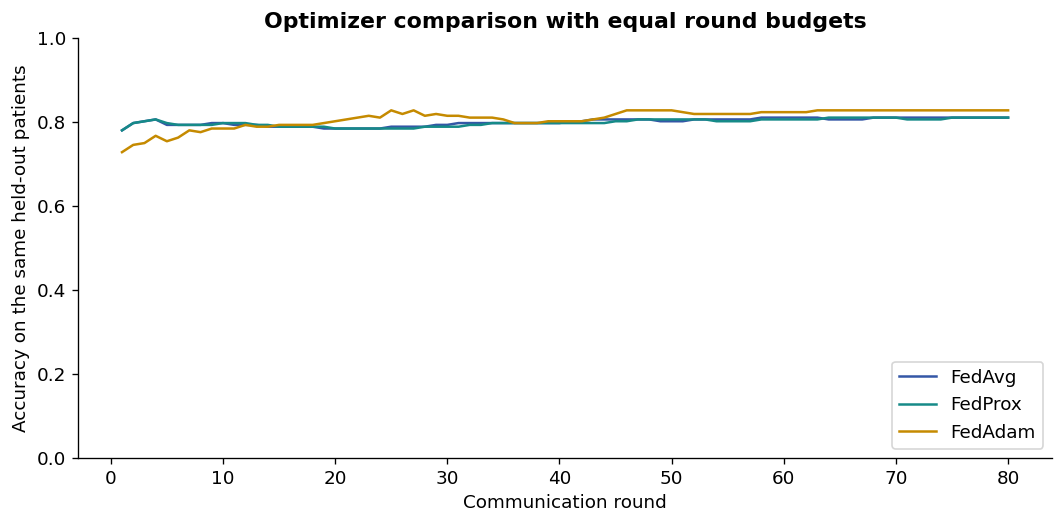

Extension checks passed; main exercise results are unchanged.


In [8]:
if RUN_OPTIMIZER_EXTENSION:
    optimizer_dir = ARTIFACT_DIR / "optimizer_extension"
    optimizer_dir.mkdir(exist_ok=True)
    core_weights_before = federated_weights.copy()
    core_predictions_before = [
        (client.test_features @ federated_weights >= 0).copy() for client in clients
    ]

    # With no proximal penalty, the local update must be the ordinary core update.
    example_features, _, example_labels, _ = next(iter(hospital_splits.values()))
    nonzero_start = np.linspace(-0.1, 0.1, NUM_PARAMETERS)
    np.testing.assert_allclose(
        train_proximal_steps(example_features, example_labels, nonzero_start, 0),
        train_steps(example_features, example_labels, nonzero_start, LOCAL_STEPS),
        rtol=0,
        atol=1e-12,
    )

    optimizer_histories = {}
    optimizer_models = {}
    for optimizer_name in ["FedAvg", "FedProx", "FedAdam"]:
        weights, history = run_optimizer(optimizer_name)
        optimizer_models[optimizer_name] = weights
        optimizer_histories[optimizer_name] = history

    # The Flower strategy adapter must reproduce the main exercise's FedAvg.
    np.testing.assert_allclose(
        optimizer_models["FedAvg"], federated_weights, rtol=0, atol=1e-12
    )
    np.testing.assert_allclose(
        optimizer_histories["FedAvg"].accuracy,
        federated_history.accuracy,
        rtol=0,
        atol=1e-12,
    )
    optimizer_table = pd.DataFrame(
        [
            {
                "method": optimizer_name,
                "rounds": ROUNDS,
                "local_steps": LOCAL_STEPS,
                "final_accuracy": history.accuracy.iloc[-1],
            }
            for optimizer_name, history in optimizer_histories.items()
        ]
    )
    display(optimizer_table.round(4))

    figure, axis = plt.subplots(figsize=(9, 4.5))
    for (optimizer_name, history), color in zip(
        optimizer_histories.items(), [BLUE, TEAL, GOLD]
    ):
        axis.plot(history["round"], history.accuracy, label=optimizer_name, color=color)
    axis.set(
        xlabel="Communication round",
        ylabel="Accuracy on the same held-out patients",
        ylim=(0, 1),
        title="Optimizer comparison with equal round budgets",
    )
    axis.legend(loc="lower right")
    figure.tight_layout()
    figure.savefig(optimizer_dir / "optimizer_comparison.png", bbox_inches="tight")
    plt.show()
    optimizer_table.to_csv(optimizer_dir / "optimizer_comparison.csv", index=False)
    pd.concat(
        [
            history.assign(method=optimizer_name)
            for optimizer_name, history in optimizer_histories.items()
        ]
    ).to_csv(optimizer_dir / "round_history.csv", index=False)

    np.testing.assert_array_equal(federated_weights, core_weights_before)
    for client, previous_predictions in zip(clients, core_predictions_before):
        np.testing.assert_array_equal(
            client.test_features @ federated_weights >= 0, previous_predictions
        )
    optimizer_checks = {
        "source": "Federated_Learning (1).ipynb",
        "same_round_and_local_step_budgets": True,
        "prox_mu_zero_matches_ordinary_update": True,
        "flower_fedavg_matches_main_exercise": True,
        "main_predictions_unchanged": True,
        "server_fedadam": "Flower 1.15.2 FedAdam.aggregate_fit",
        "proximal_mu": EXT_PROX_MU,
        "adam_eta": EXT_ADAM_ETA,
        "adam_beta1": EXT_ADAM_BETA1,
        "adam_beta2": EXT_ADAM_BETA2,
        "adam_tau": EXT_ADAM_TAU,
    }
    (optimizer_dir / "checks.json").write_text(json.dumps(optimizer_checks, indent=2))
    print("Extension checks passed; main exercise results are unchanged.")
else:
    print("Optimizer comparison skipped.")


### Read the comparison

FedProx changes the local optimization objective; FedAdam changes the server update.
The methods use the same numbers of rounds and local steps, with different method-specific
hyperparameters. One run does not show that any method is always better. Change one parameter
at a time, and use a validation split to select settings.

Methods: [FedProx](https://arxiv.org/abs/1812.06127),
[Adaptive Federated Optimization](https://arxiv.org/abs/2003.00295).
